# Baseline and Benchmark Analysis

This notebook analyzes existing benchmark artifacts only. It does not rerun benchmarks and does not call OpenAI, Pinecone, or local LoRA models.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either repo-root or notebooks/ execution."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "SMSSpamCollection").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find project root containing data/SMSSpamCollection and src/.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "SMSSpamCollection"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
print(f"Project root: {PROJECT_ROOT.relative_to(PROJECT_ROOT)} (resolved internally)")

Project root: . (resolved internally)


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

RESULTS_PATH = OUTPUTS_DIR / "benchmark_results.csv"
PREDICTIONS_PATH = OUTPUTS_DIR / "benchmark_predictions.csv"
SUMMARY_PATH = OUTPUTS_DIR / "benchmark_summary.md"
CONFUSION_PATH = OUTPUTS_DIR / "confusion_matrices.png"

required = [RESULTS_PATH, PREDICTIONS_PATH, SUMMARY_PATH]
missing = [path.relative_to(PROJECT_ROOT) for path in required if not path.exists()]
HAVE_FILES = not missing
if missing:
    missing_text = ", ".join(str(p) for p in missing)
    display(Markdown(f"""**Missing benchmark artifacts.** Run this from the repo root before using this notebook:

```bash
python -m src.benchmark --modes tfidf_lr,base_llm,basic_rag,advanced_base,advanced_lora,guarded_fallback --sample-size 30
```

Missing: {missing_text}"""))
else:
    print("Benchmark artifacts found.")

Benchmark artifacts found.


## Benchmark Summary File

The generated Markdown summary is displayed first so the notebook mirrors the CLI report.

In [3]:
if HAVE_FILES:
    display(Markdown(SUMMARY_PATH.read_text(encoding="utf-8")))

# Benchmark Summary

_This benchmark uses a stratified held-out test sample. LLM/RAG modes may be run on smaller samples to control API cost._

## Run config

- canonical split: `test_size=0.2`, `seed=42`
- sample-size argument: 30 (effective: 30)
- random seed: 42
- spam ratio in sample: 0.133

## Results

| mode | n | acc | P_macro | R_macro | F1_macro | spam_recall | ham_recall | TP | FP | FN | TN | avg_latency_s | errors |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| tfidf_lr | 30 | 0.9667 | 0.9815 | 0.8750 | 0.9191 | 0.7500 | 1.0000 | 3 | 0 | 1 | 26 | 0.0001 | 0 |
| base_llm | 30 | 0.8667 | 0.7292 | 0.8173 | 0.7600 | 0.7500 | 0.8846 | 3 | 3 | 1 | 23 | 0.8539 | 0 |
| basic_rag | 30 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 4 | 0 | 0 | 26 | 1.4625 | 0 |
| advanced_base | 30 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 4 | 0 | 0 | 26 | 5.6724 | 0 |
| advanced_lora | 30 | 0.8667 | 0.4333 | 0.5000 | 0.4643 | 0.0000 | 1.0000 | 0 | 0 | 4 | 26 | 11.0517 | 0 |
| guarded_fallback | 30 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 1.0000 | 4 | 0 | 0 | 26 | 11.3166 | 0 |


## Results Table

The CSV table is the source of truth for metrics and plotting.

In [4]:
if HAVE_FILES:
    results = pd.read_csv(RESULTS_PATH)
    predictions = pd.read_csv(PREDICTIONS_PATH)
    display(results)
    print(f"Prediction rows: {len(predictions):,}")

,mode,n_samples,accuracy,precision_macro,recall_macro,f1_macro,spam_recall,ham_recall,tp,fp,fn,tn,error_count,avg_latency_s
0,tfidf_lr,30,0.966667,0.981481,0.875000,0.919137,0.75,1.000000,3,0,1,26,0,0.0001
1,base_llm,30,0.866667,0.729167,0.817308,0.760000,0.75,0.884615,3,3,1,23,0,0.8539
2,basic_rag,30,1.000000,1.000000,1.000000,1.000000,1.00,1.000000,4,0,0,26,0,1.4625
3,advanced_base,30,1.000000,1.000000,1.000000,1.000000,1.00,1.000000,4,0,0,26,0,5.6724
4,advanced_lora,30,0.866667,0.433333,0.500000,0.464286,0.00,1.000000,0,0,4,26,0,11.0517
5,guarded_fallback,30,1.000000,1.000000,1.000000,1.000000,1.00,1.000000,4,0,0,26,0,11.3166


Prediction rows: 180


## Accuracy, Macro F1, and Spam Recall

These plots compare overall correctness, class-balanced F1, and the spam-specific recall that matters most for missed spam.

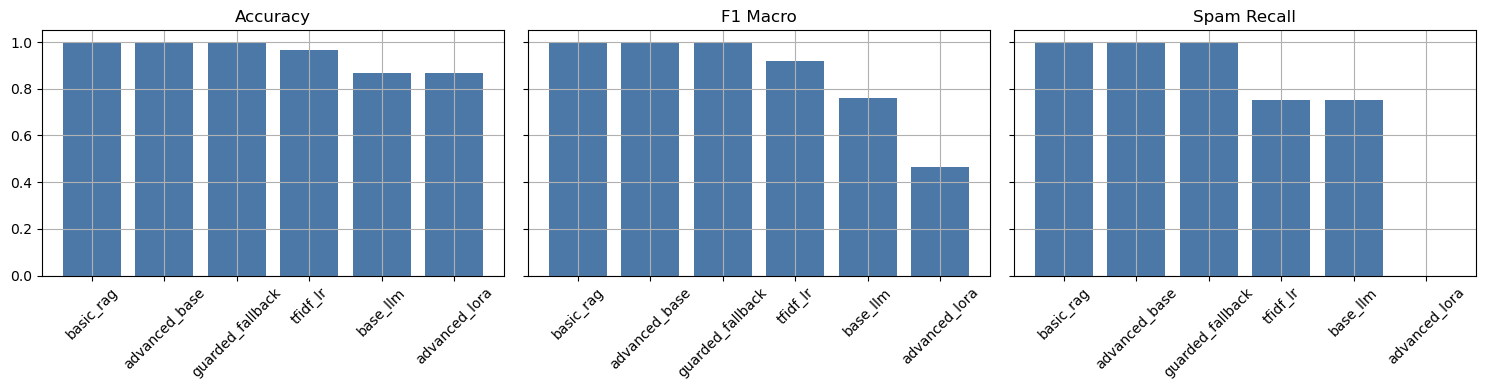

In [5]:
if HAVE_FILES:
    metric_cols = ["accuracy", "f1_macro", "spam_recall"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, metric in zip(axes, metric_cols):
        ordered = results.sort_values(metric, ascending=False)
        ax.bar(ordered["mode"], ordered[metric], color="#4C78A8")
        ax.set_title(metric.replace("_", " ").title())
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

TF-IDF is a strong classical baseline. The base LLM is weaker without retrieval, while Basic RAG and Advanced Base perform strongly on this sample. Advanced LoRA fails on spam recall, and Guarded Fallback recovers those LoRA failures.

## Average Latency by Mode

Latency is part of the system trade-off: the classical baseline is fastest, while agentic modes do more orchestration.

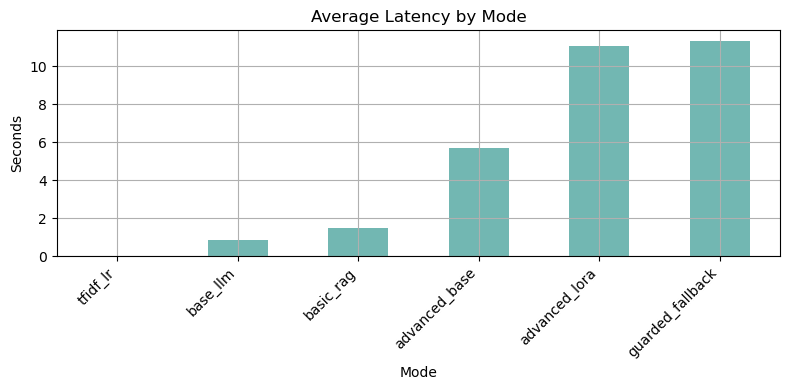

In [6]:
if HAVE_FILES:
    ordered = results.sort_values("avg_latency_s")
    ax = ordered.plot(kind="bar", x="mode", y="avg_latency_s", legend=False, color="#72B7B2")
    ax.set_title("Average Latency by Mode")
    ax.set_xlabel("Mode")
    ax.set_ylabel("Seconds")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

The speed-quality trade-off is visible: TF-IDF is extremely fast and competitive, while retrieval and verifier/fallback logic add latency in exchange for stronger grounded behavior.

## Confusion Matrices

If the Phase 3 image exists, display it directly instead of regenerating plots.

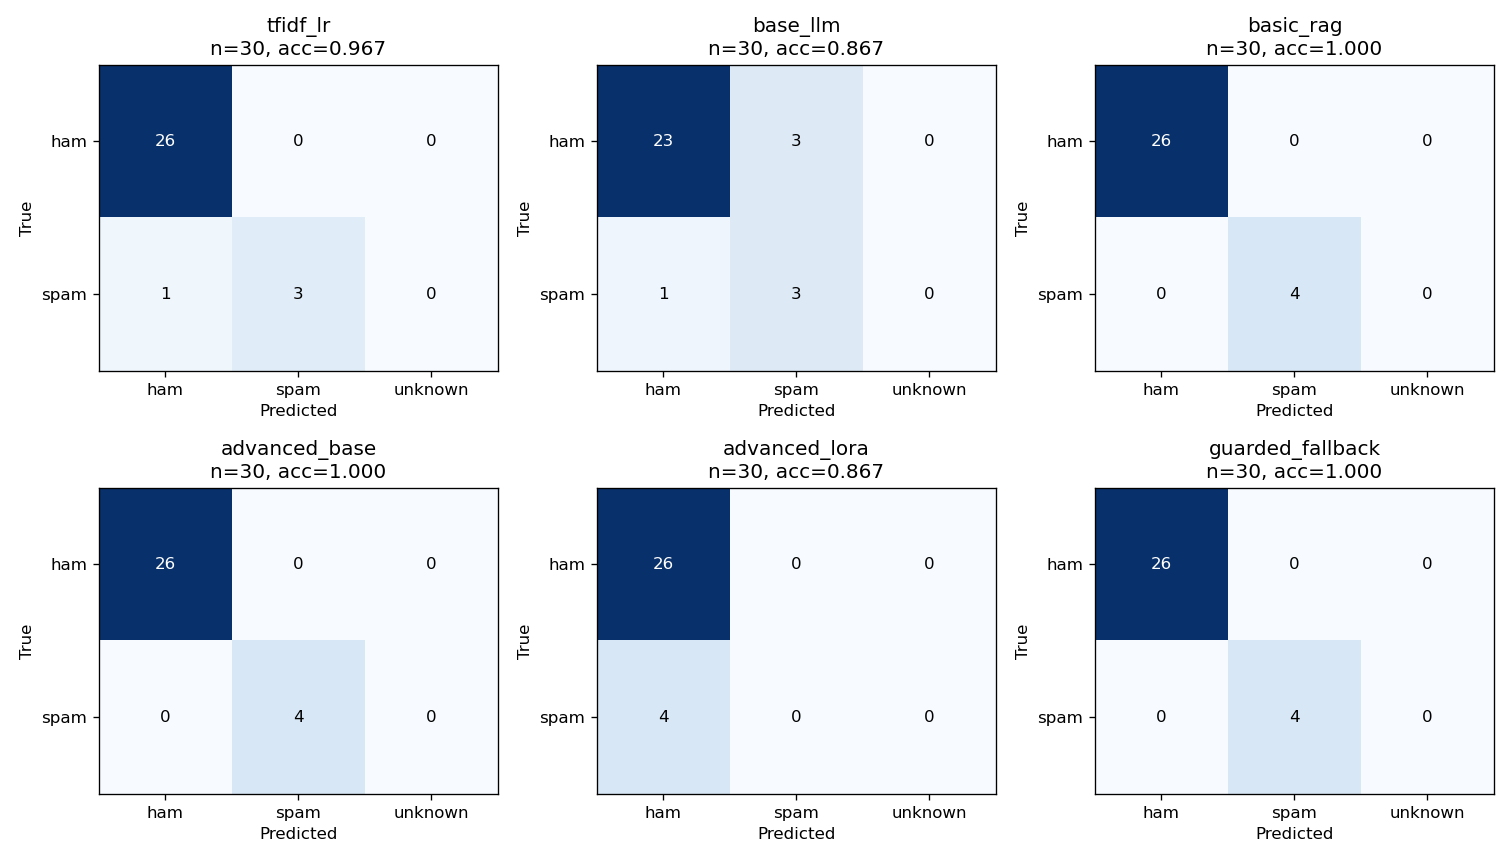

In [7]:
if HAVE_FILES:
    if CONFUSION_PATH.exists():
        display(Image(filename=str(CONFUSION_PATH)))
    else:
        display(Markdown("`outputs/confusion_matrices.png` was not found. The CSV metrics above are still available."))

## Takeaways

- TF-IDF is a strong, fast classical baseline.
- Base LLM is weaker without retrieval grounding.
- Basic RAG and Advanced Base perform strongly on this benchmark sample.
- Advanced LoRA is locally integrated but misses spam in this run.
- Guarded Fallback provides the reliability improvement by falling back when LoRA output is unsupported.